# Slide figures — sampling distributions & equations

One notebook to generate everything for the deck, in a consistent look: **white glyphs, transparent background**, tightly cropped.

- Every figure is saved to `slide_images/<name>.png` (transparent) and previewed inline on a dark panel so the white ink is visible.
- Plots use matplotlib. Equations shell out to your `pdflatex` + `pdftocairo` (identical to the `.tex` files), so no `usetex`/`dvipng` needed.
- To place a figure on a slide: drag the PNG from `slide_images/`, or right-click the inline preview → *Save image as*.

In [80]:
import os, subprocess, tempfile, base64
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import HTML, display, Image

OUT = "slide_images"
os.makedirs(OUT, exist_ok=True)
rng = np.random.default_rng(0)

# palette (tweak to match your template)
BLUE, GREEN, GOLD, RED = "#8ab4ff", "#7ee0b8", "#ffd479", "#ff8a8a"
PREVIEW_BG = "#1e1e28"   # inline preview only; saved files stay transparent

# --- shared slide style: white fonts, transparent axes ---
plt.rcParams.update({
    "font.size": 16, "mathtext.fontset": "cm",
    "text.color": "white", "axes.labelcolor": "white", "axes.titlecolor": "white",
    "axes.edgecolor": "white", "xtick.color": "white", "ytick.color": "white",
    "axes.facecolor": "none", "figure.facecolor": PREVIEW_BG,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "savefig.dpi": 200,
})

def _preview(png):
    display(Image(filename=png))   # native image output -> copy button returns, transparency preserved
    
# def _preview(png):
#     """Show a transparent PNG on a dark panel so white ink is visible in the notebook."""
#     b64 = base64.b64encode(open(png, "rb").read()).decode()
#     display(HTML(f'<div style="background:{PREVIEW_BG};display:inline-block;padding:10px;border-radius:6px">'
#                  f'<img src="data:image/png;base64,{b64}"></div>'))

def save(fig, name):
    """Save a matplotlib figure as a transparent PNG and preview it."""
    path = f"{OUT}/{name}.png"
    fig.savefig(path, transparent=True, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)
    _preview(path)
    return path

_TEX = r"""\documentclass[border=6pt]{standalone}
\usepackage{amsmath,amssymb}
\usepackage{xcolor}
\begin{document}\color{white}
%s
\end{document}"""

def eq(body, name, r=300):
    """Render a LaTeX equation to a transparent white PNG via pdflatex + pdftocairo.
    `body` is the math, e.g. r'$\\displaystyle \\bar X_n \\approx N(\\mu,\\sigma^2/n)$'."""
    d = tempfile.mkdtemp(); tex = os.path.join(d, "e.tex")
    with open(tex, "w") as f:
        f.write(_TEX % body)
    subprocess.run(["pdflatex", "-interaction=nonstopmode", "-halt-on-error",
                    "-output-directory", d, tex], check=True, capture_output=True)
    base = f"{OUT}/{name}"
    subprocess.run(["pdftocairo", "-png", "-transp", "-r", str(r), "-singlefile",
                    os.path.join(d, "e.pdf"), base], check=True)
    _preview(base + ".png")
    return base + ".png"

print("helpers ready — figures go to", os.path.abspath(OUT))

helpers ready — figures go to /Users/ppopov1/playground/stats_presentation/slide_images


## Equations

Same output as the standalone `.tex` files, but inline. Use `$\displaystyle ...$` for full-size fractions.

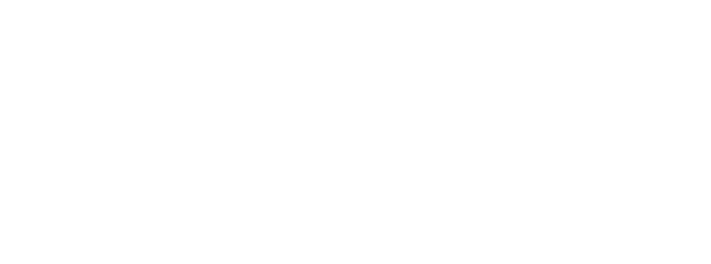

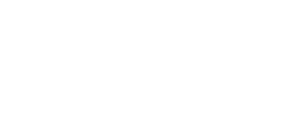

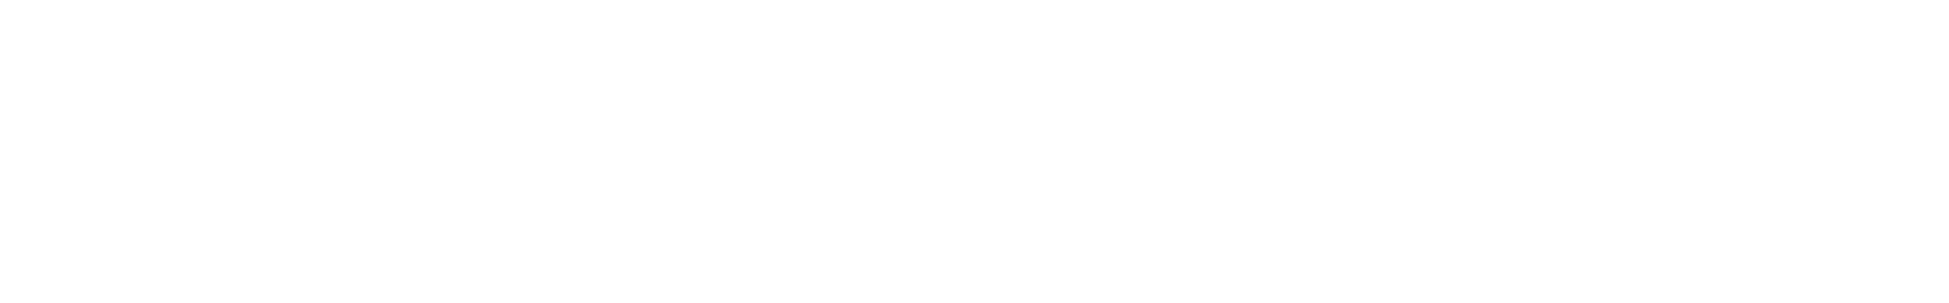

'slide_images/eq_clt.png'

In [82]:
eq(r"""$\displaystyle
\begin{gathered}
X_1,\dots,X_n \overset{\text{iid}}{\sim} P, \qquad \bar X_n=\frac{1}{n}\sum_{i=1}^{n}X_i\\[6pt]
\mu=\mathbb{E}_{P}[X_i],\quad \sigma^2=\mathbb{E}_{P}\!\big[(X_i-\mu)^2\big]
\end{gathered}$""", "eq_setup")
eq(r"$\displaystyle \bar X_n \;\xrightarrow[\,n\to\infty\,]{\text{a.s.}}\; \mu$", "eq_lln")
eq(r"""$\displaystyle \frac{\bar X_n-\mu}{\sigma/\sqrt{n}} \;\xrightarrow{\,d\,}\; N(0,1)
\quad\Longleftrightarrow\quad
\bar X_n \;\xrightarrow{\,d\,}\; N\!\left(\mu,\ \frac{\sigma^{2}}{n}\right)$""", "eq_clt", r=600)

## Funnel — LLN and CLT in one frame

Many running-average trajectories vs `n`. They **funnel to the true mean (LLN)**, and the funnel's width at each `n` is the **$\pm1.96\,\sigma/\sqrt{n}$ band (CLT)** — the seed of the standard error.

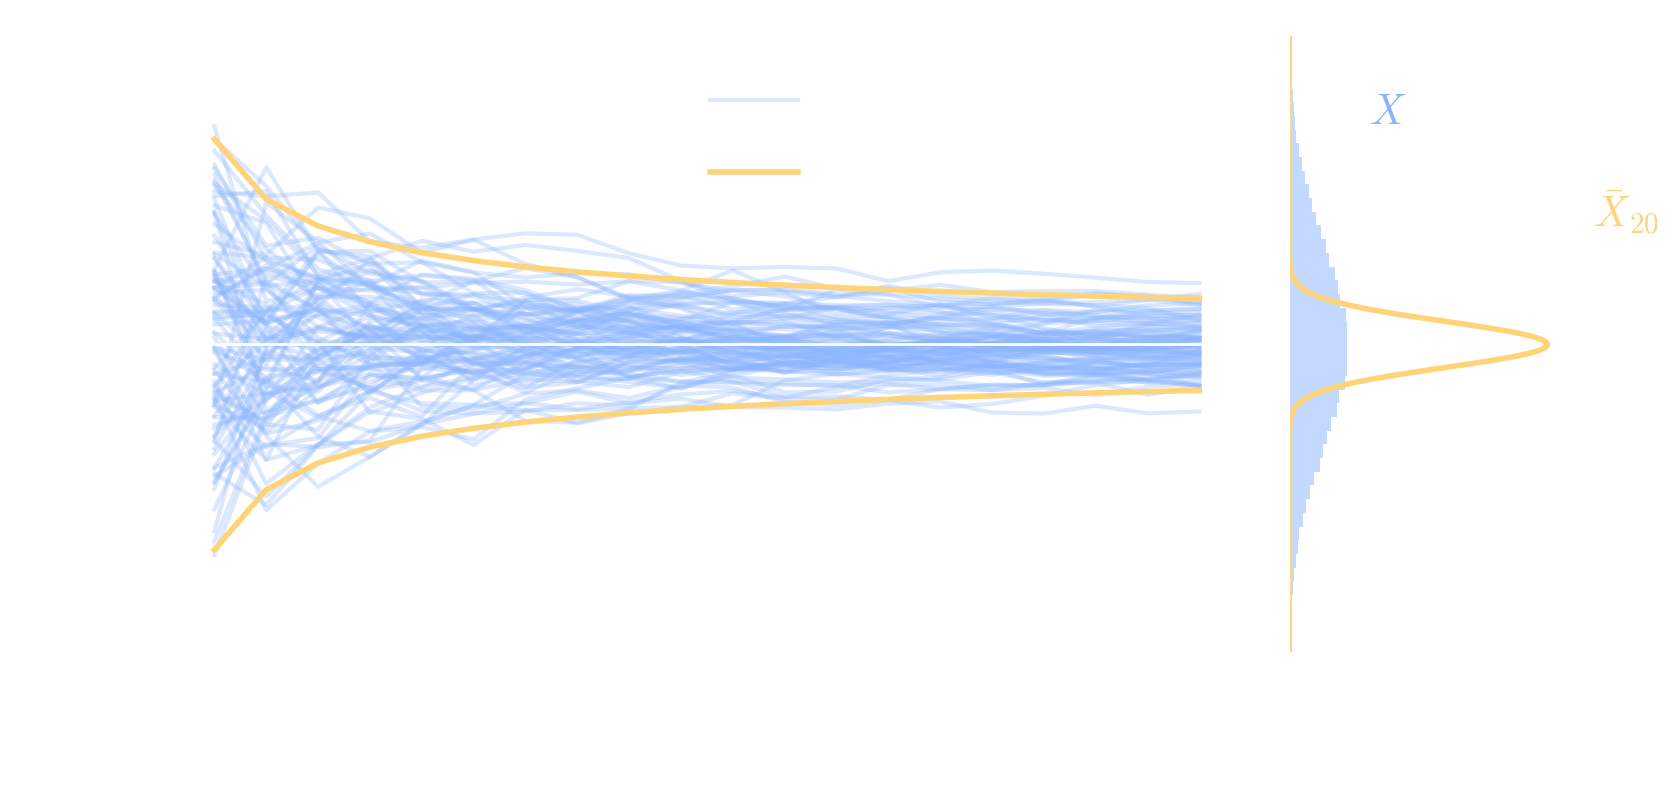

'slide_images/funnel.png'

In [ ]:
n_max = 20
paths_show = 100
paths_dist = 40000

Xd = rng.normal(0, 1, size=(paths_dist, n_max))
run = np.cumsum(Xd, axis=1) / np.arange(1, n_max + 1)
ns = np.arange(1, n_max + 1)

fig, (ax, axr) = plt.subplots(1, 2, figsize=(9, 4), sharey=True,
                              gridspec_kw={"width_ratios": [4, 1], "wspace": 0.06})

# --- funnel: running averages + CLT band ---
lines = ax.plot(ns, run[:paths_show].T, color=BLUE, alpha=0.3)
lines[0].set_label(r"one run of $\bar X_n$")
ax.axhline(0, color="white", lw=1)                  # true mean mu (LLN target)
ax.plot(ns,  2 / np.sqrt(ns), color=GOLD, lw=2, label=r"$\pm 2\,\sigma/\sqrt{n}$  (≈95%)")
ax.plot(ns, -2 / np.sqrt(ns), color=GOLD, lw=2)
ax.set_xlabel("n"); ax.set_ylabel(r"$\bar X_n$"); ax.set_ylim(-3, 3); ax.legend(loc="upper right")

# --- right marginal: distribution of one draw X vs the mean X-bar_n ---
yy = np.linspace(-3, 3, 300)
axr.hist(Xd[:, 0], bins=60, density=True, orientation="horizontal", color=BLUE, alpha=0.5)
sd = 1 / np.sqrt(n_max)
axr.plot(np.exp(-yy**2 / (2*sd**2)) / (sd*np.sqrt(2*np.pi)), yy, color=GOLD, lw=2)
axr.set_xticks([]); axr.set_xlabel("density")
axr.text(0.55, 2.15, r"$X$", color=BLUE, fontsize=15)
axr.text(2.10, 1.15, rf"$\bar X_{{{n_max}}}$", color=GOLD, fontsize=15)
for s in ("top", "right", "bottom"):
    axr.spines[s].set_visible(False)

save(fig, "funnel")

## Dice demo — uniform → triangle → bell

Sum of `k` dice: 1 die is flat, 2 dice is a triangle, 3–4 dice already look bell-shaped.

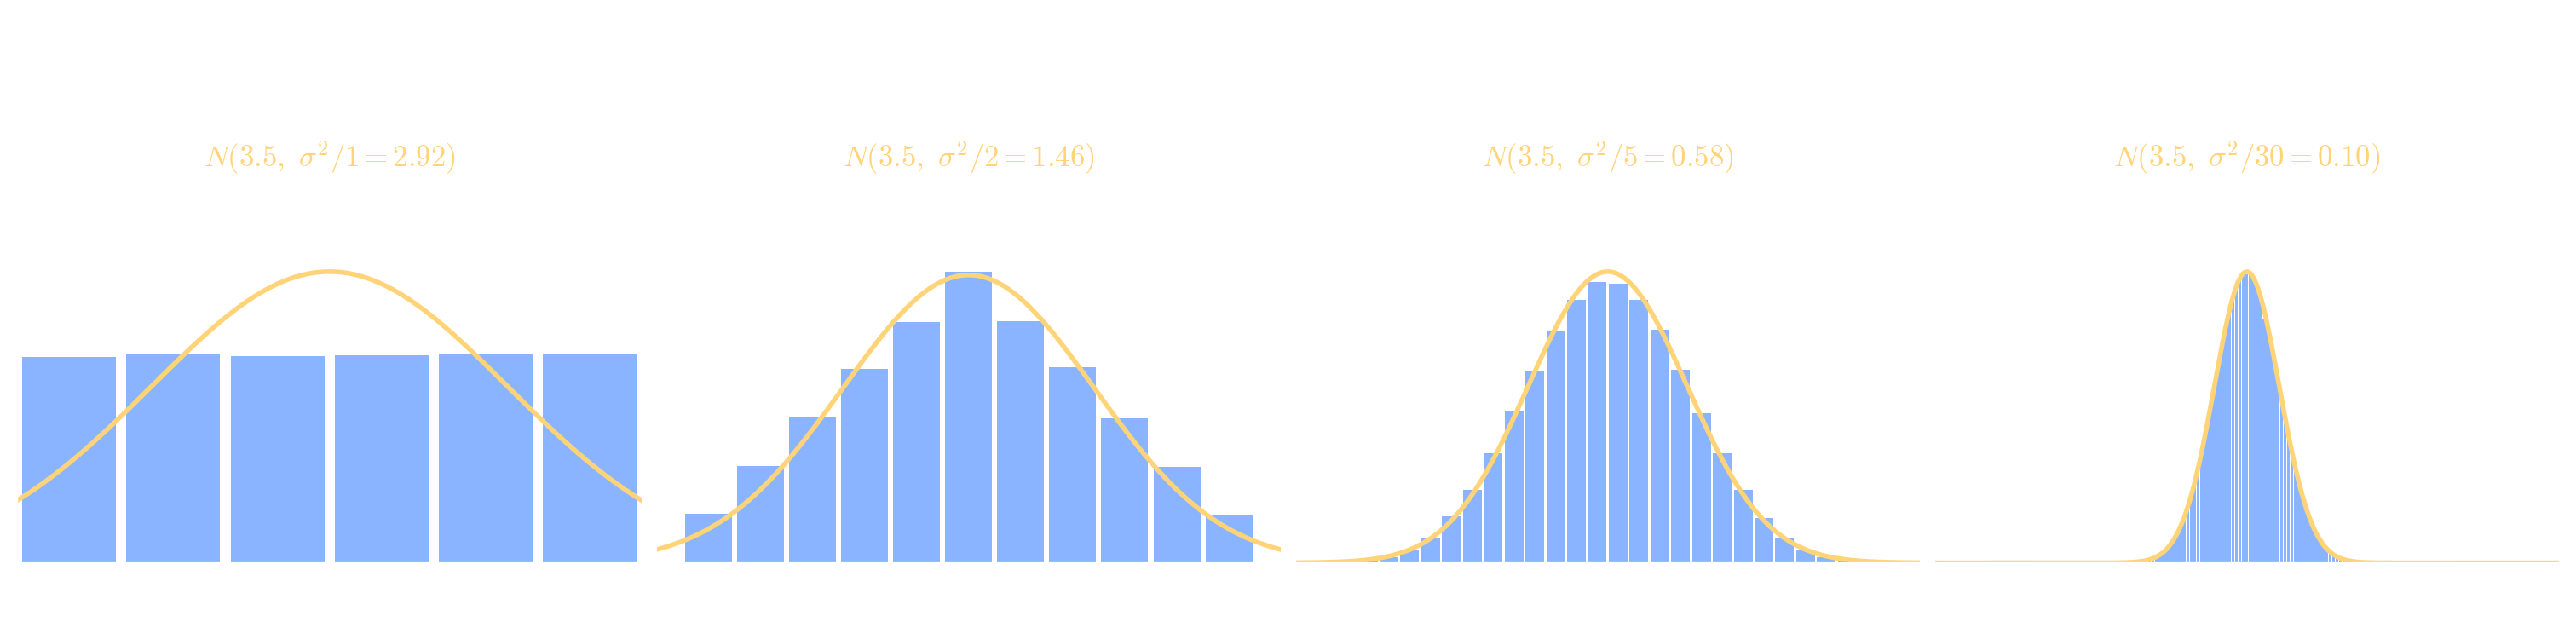

'slide_images/dice.png'

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
mu, var1 = 3.5, 35 / 12          # mean & variance of one fair die
for ax, k in zip(axes, [1, 2, 5, 30]):
    rolls = rng.integers(1, 7, size=(300000, k)).mean(1)
    vals, counts = np.unique(rolls, return_counts=True)
    density = counts / counts.sum() * k                 # probability -> density (spacing = 1/k)
    ax.bar(vals, density, color=BLUE, width=0.9 / k)
    # CLT prediction: mean of k dice ~ N(3.5, var1/k)
    x = np.linspace(0.5, 6.5, 400); sd = np.sqrt(var1 / k)
    peak = 1 / (sd * np.sqrt(2 * np.pi))
    ax.plot(x, peak * np.exp(-(x - mu) ** 2 / (2 * sd ** 2)), color=GOLD, lw=2)
    ax.set_title(f"n = {k}")
    ax.text(0.5, 0.97, rf"$N(3.5,\ \sigma^2/{k}={var1/k:.2f})$", transform=ax.transAxes,
            color=GOLD, fontsize=12.5, ha="center", va="top")
    ax.set_ylim(0, 1.5 * max(density.max(), peak))       # headroom so the label clears the curve
    ax.set_xticks(range(1, 7)); ax.set_xlim(0.5, 6.5); ax.set_yticks([])
fig.suptitle("Dice example", fontsize=20)
save(fig, "dice")

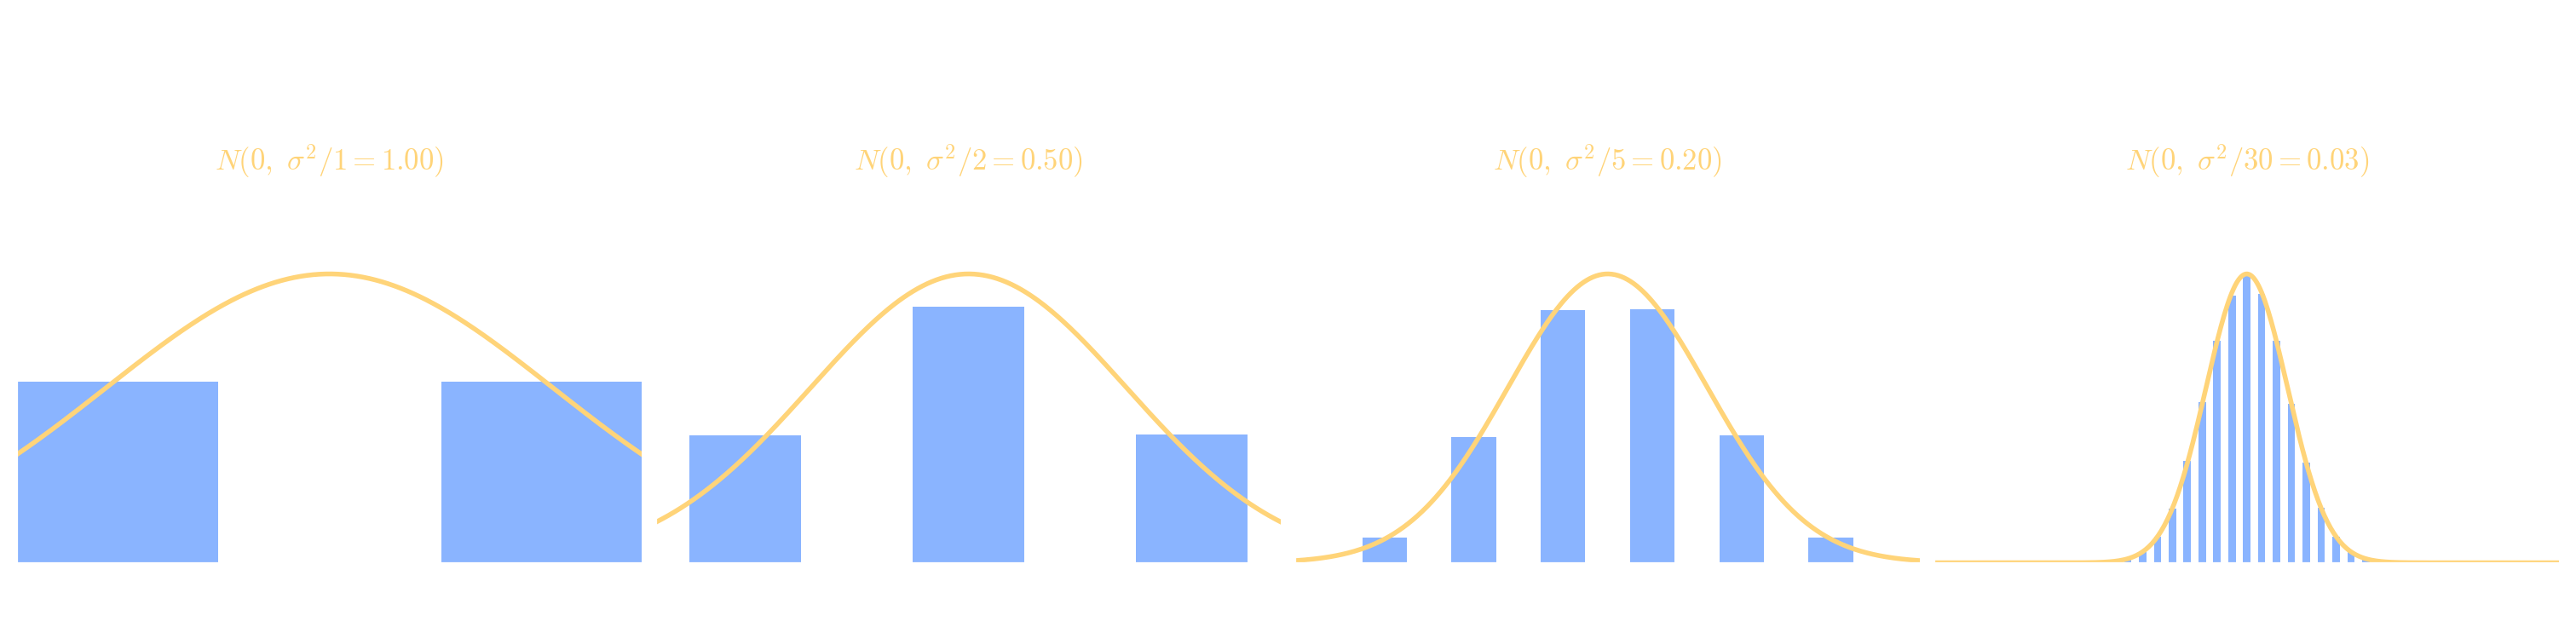

'slide_images/bimodal_clt.png'

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
mu, var1 = 0.0, 1.0          # X in {-1, +1}: mean 0, variance E[X^2] = 1
for ax, k in zip(axes, [1, 2, 5, 30]):
    means = rng.choice([-1.0, 1.0], size=(300000, k)).mean(1)
    vals, counts = np.unique(means, return_counts=True)
    density = counts / counts.sum() * (k / 2)           # spacing between means = 2/k
    ax.bar(vals, density, color=BLUE, width=1 / k)
    # CLT prediction: mean of k draws ~ N(0, var1/k)
    x = np.linspace(-1.4, 1.4, 400); sd = np.sqrt(var1 / k)
    peak = 1 / (sd * np.sqrt(2 * np.pi))
    ax.plot(x, peak * np.exp(-(x - mu) ** 2 / (2 * sd ** 2)), color=GOLD, lw=2)
    ax.set_title(f"n = {k}")
    ax.text(0.5, 0.97, rf"$N(0,\ \sigma^2/{k}={var1/k:.2f})$", transform=ax.transAxes,
            color=GOLD, fontsize=12.5, ha="center", va="top")
    ax.set_ylim(0, 1.5 * max(density.max(), peak))
    ax.set_xticks([-1, 0, 1]); ax.set_xlim(-1.4, 1.4); ax.set_yticks([])
fig.suptitle(r"Bimodal example  ($X=\pm 1$)", fontsize=20)
save(fig, "bimodal_clt")

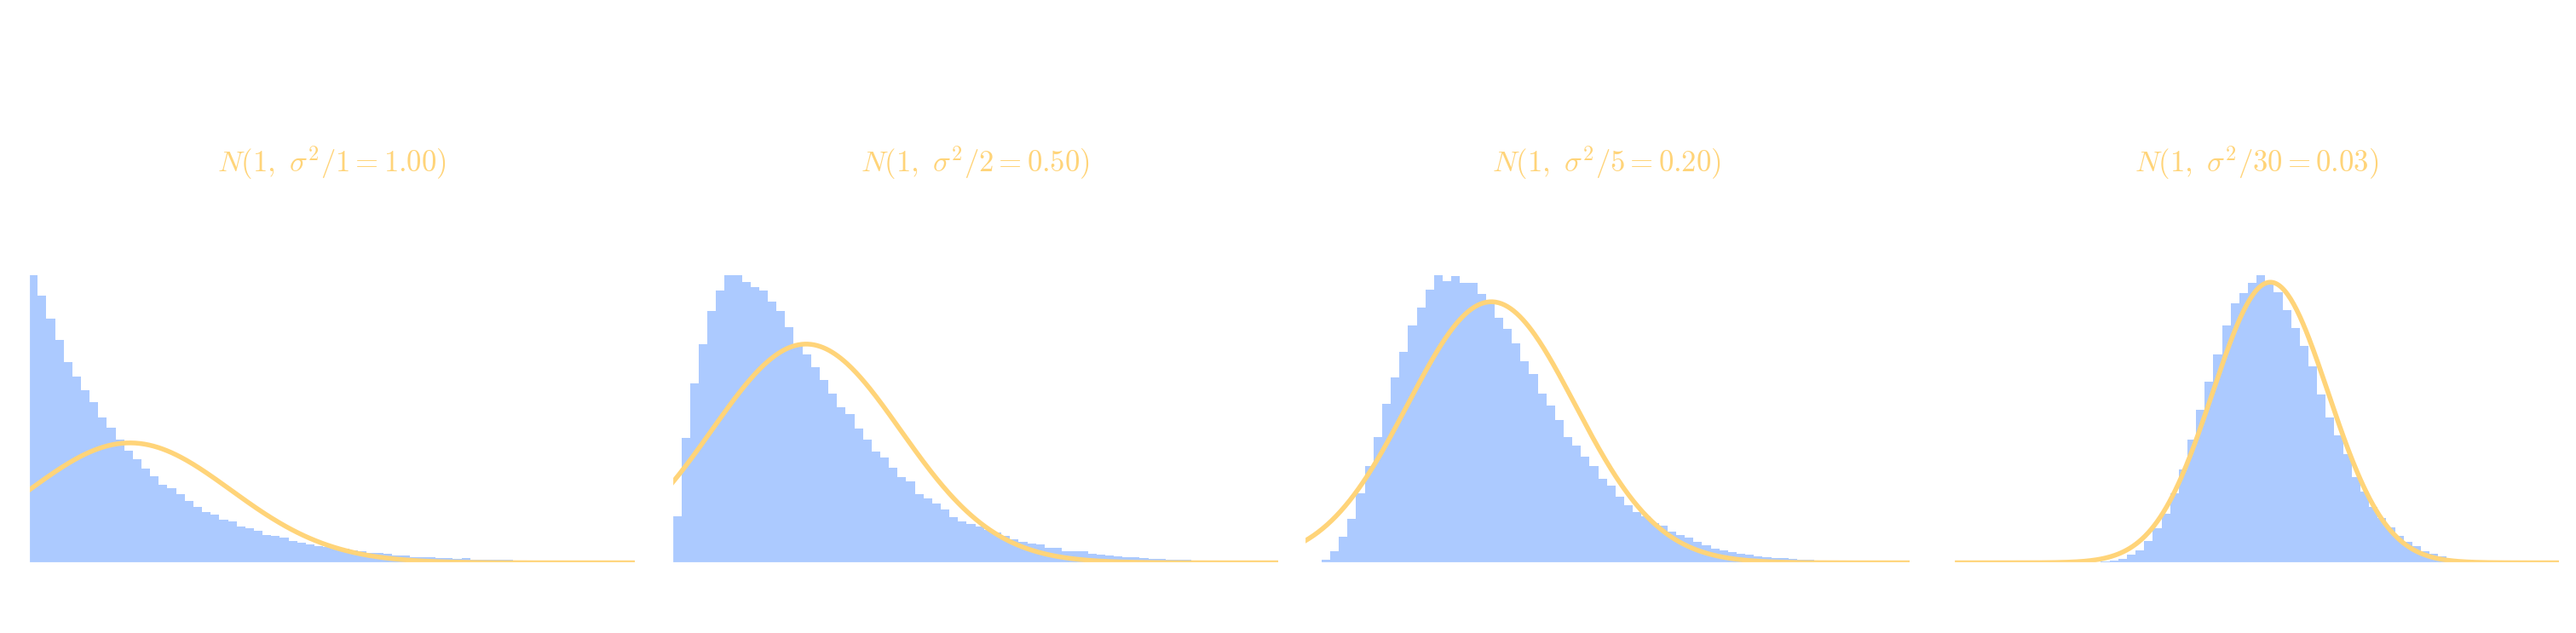

'slide_images/exponential_clt.png'

In [64]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
mu, var1 = 1.0, 1.0          # Exp(1): mean 1, variance 1
for ax, k in zip(axes, [1, 2, 5, 30]):
    means = rng.exponential(1.0, size=(200_000, k)).mean(1)
    sd = np.sqrt(var1 / k); hi = mu + 5 * sd
    counts, _, _ = ax.hist(means, bins=70, range=(0, hi), density=True, color=BLUE, alpha=0.7)
    # CLT prediction: mean of k draws ~ N(1, var1/k)
    x = np.linspace(0, hi, 400); peak = 1 / (sd * np.sqrt(2 * np.pi))
    ax.plot(x, peak * np.exp(-(x - mu) ** 2 / (2 * sd ** 2)), color=GOLD, lw=2)
    ax.set_title(f"n = {k}")
    ax.text(0.5, 0.97, rf"$N(1,\ \sigma^2/{k}={var1/k:.2f})$", transform=ax.transAxes,
            color=GOLD, fontsize=12.5, ha="center", va="top")
    ax.set_ylim(0, 1.5 * max(counts.max(), peak))
    ax.set_xlim(0, hi); ax.set_yticks([])
fig.suptitle(r"Exponential example  ($X\sim\mathrm{Exp}(1)$)", fontsize=20)
save(fig, "exponential_clt")

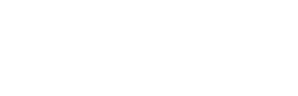

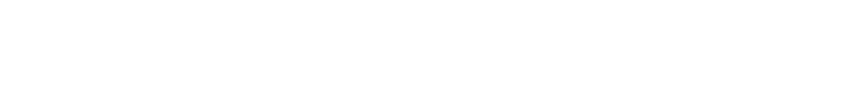

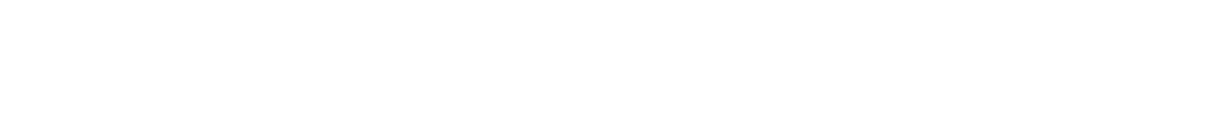

'slide_images/eq_exp_moments.png'

In [66]:
# Exponential pdf: general rate lambda -> standard (lambda = 1)
eq(r"""$\displaystyle
\mathrm{Exp}(1)=e^{-x}$""", "eq_exp_pdf")

eq(r"""$\displaystyle
f(x)=\lambda e^{-\lambda x},\ \ x\ge 0
\quad\xrightarrow{\;\lambda=1\;}\quad
f(x)=e^{-x}$""", "eq_exp_pdf")

# Moments: mean 1/lambda, variance 1/lambda^2 -> both 1 at lambda = 1
eq(r"""$\displaystyle
\mu=\mathbb{E}[X]=\frac{1}{\lambda},\qquad
\sigma^{2}=\operatorname{Var}(X)=\frac{1}{\lambda^{2}}
\quad\xrightarrow{\;\lambda=1\;}\quad \mu=1,\ \sigma^{2}=1$""", "eq_exp_moments")

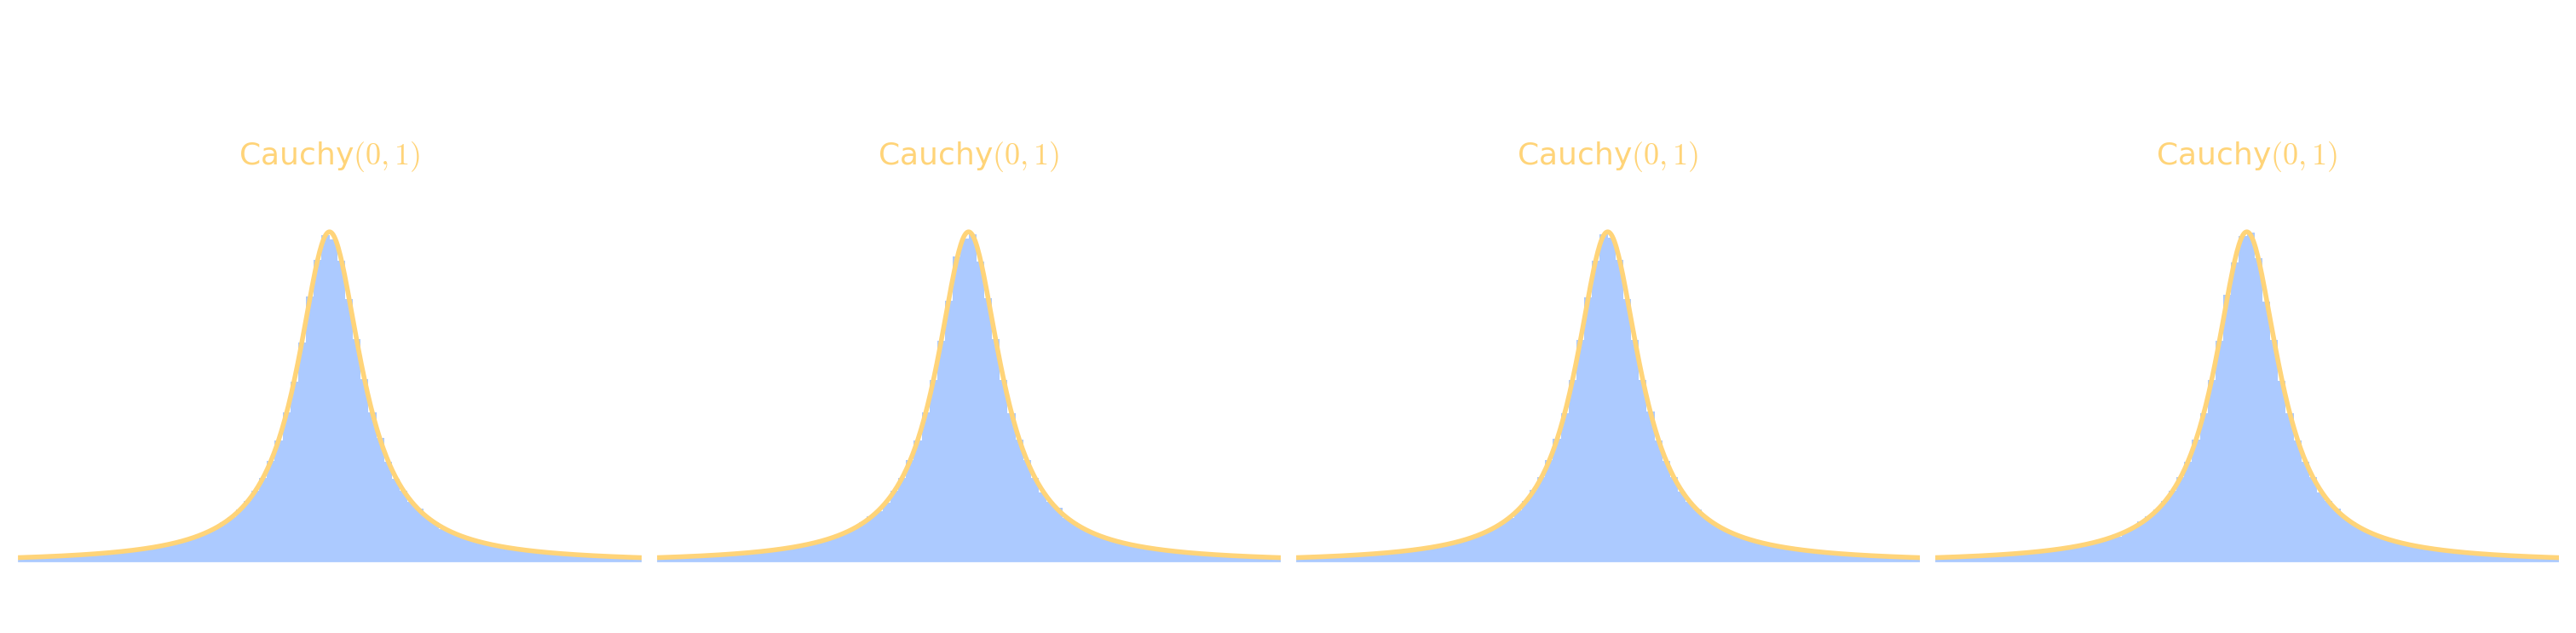

'slide_images/cauchy_clt.png'

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
N = 400_000; lo, hi = -8, 8
edges = np.linspace(lo, hi, 81); binw = edges[1] - edges[0]
centers = (edges[:-1] + edges[1:]) / 2
xx = np.linspace(lo, hi, 600); cauchy = 1 / (np.pi * (1 + xx ** 2))   # standard Cauchy pdf
for ax, k in zip(axes, [1, 2, 5, 300]):
    means = rng.standard_cauchy((N, k)).mean(1)
    counts, _ = np.histogram(means, bins=edges)
    density = counts / (N * binw)                    # normalize by ALL draws (matches pdf mass in view)
    ax.bar(centers, density, width=binw, color=BLUE, alpha=0.7)
    ax.plot(xx, cauchy, color=GOLD, lw=2)            # SAME curve every panel
    frac_out = np.mean(np.abs(means) > hi) * 100
    ax.set_title(f"n = {k}")
    ax.text(0.5, 0.97, r"Cauchy$(0,1)$", transform=ax.transAxes, color=GOLD,
            fontsize=13, ha="center", va="top")
    ax.set_xticks([-5, 0, 5]); ax.set_xlim(lo, hi); ax.set_ylim(0, 0.42); ax.set_yticks([])
fig.suptitle("Cauchy example  (infinite variance)", fontsize=20)
save(fig, "cauchy_clt")

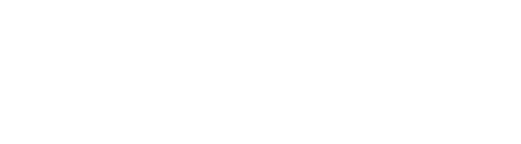

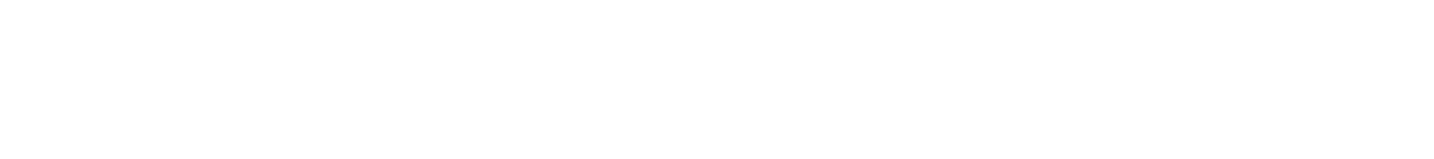

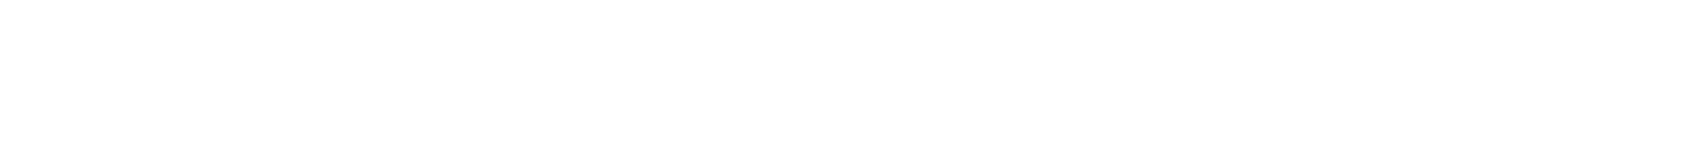

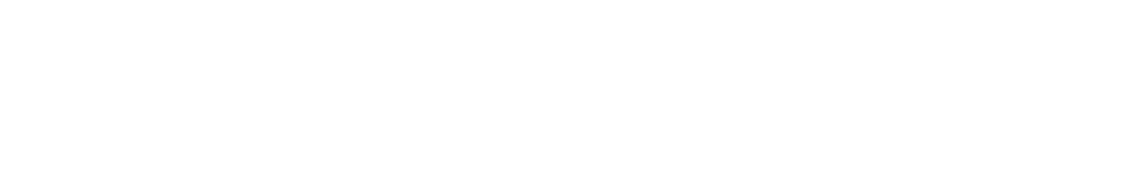

'slide_images/eq_cauchy_stable.png'

In [61]:
# Cauchy pdf: general (location x0, scale gamma) -> standard
eq(r"""$\displaystyle
\text{Cauchy}(0,1)=\frac{1}{\pi\,(1+x^{2})}$""", "eq_cauchy_pdf")

# Mean undefined (integral not absolutely convergent)
# Mean: antiderivative is a log, evaluates to "infinity minus infinity" -> undefined
eq(r"""$\displaystyle
\mathbb{E}[X]=\int_{-\infty}^{\infty}\frac{x}{\pi(1+x^{2})}\,dx
=\left[\frac{\ln(1+x^{2})}{2\pi}\right]_{-\infty}^{\infty}
=\ \text{``}\infty-\infty\text{''}\ \ \Rightarrow\ \mu\ \text{undefined}$""", "eq_cauchy_mean")

# Second moment infinite; variance undefined because the mean doesn't exist
eq(r"""$\displaystyle
\mathbb{E}[X^{2}]=\int_{-\infty}^{\infty}\frac{x^{2}}{\pi(1+x^{2})}\,dx=\infty,
\qquad \operatorname{Var}(X)=\mathbb{E}\big[(X-\mu)^{2}\big]\ \text{undefined}\ \ (\mu\ \text{does not exist})$""", "eq_cauchy_var")

# Punchline: the sample mean stays Cauchy for every n (why there's no collapse)
eq(r"""$\displaystyle
X_i\sim\text{Cauchy}(0,1)\ \Longrightarrow\
\bar X_n=\frac{1}{n}\sum_{i=1}^{n}X_i\sim\text{Cauchy}(0,1)\quad\forall\,n$""", "eq_cauchy_stable")

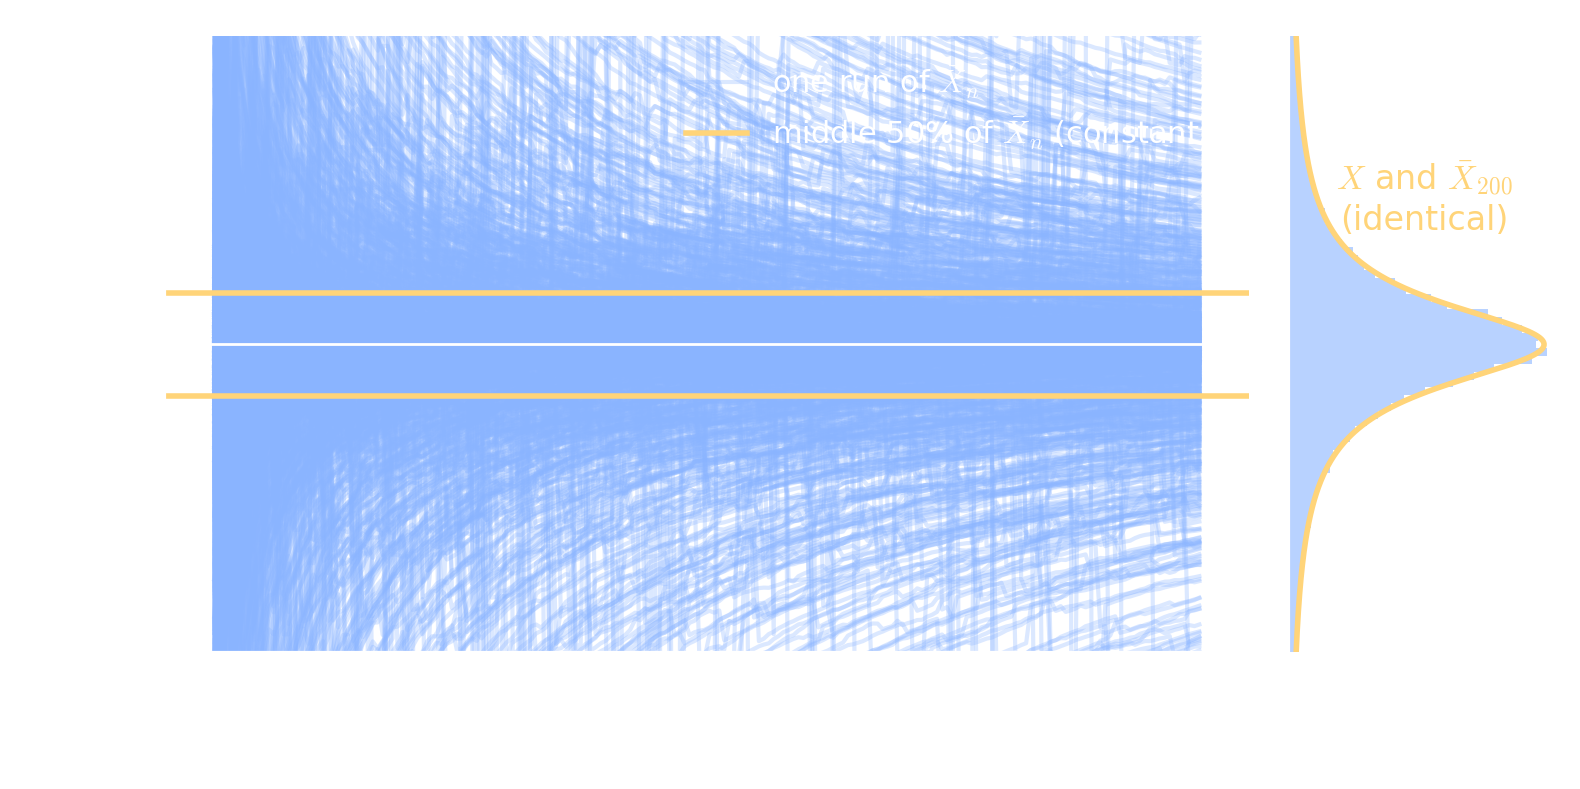

'slide_images/funnel_cauchy.png'

In [87]:
n_max = 200; paths_show = 1000; paths_dist = 40_000
Xc = rng.standard_cauchy((paths_dist, n_max))
run = np.cumsum(Xc, axis=1) / np.arange(1, n_max + 1)
ns = np.arange(1, n_max + 1)

fig, (ax, axr) = plt.subplots(1, 2, figsize=(9, 4), sharey=True,
                              gridspec_kw={"width_ratios": [4, 1], "wspace": 0.06})
lines = ax.plot(ns, run[:paths_show].T, color=BLUE, alpha=0.3)
lines[0].set_label(r"one run of $\bar X_n$")
ax.axhline(0, color="white", lw=1)
ax.axhline( 1, color=GOLD, lw=2, label=r"middle 50% of $\bar X_n$ (constant!)")
ax.axhline(-1, color=GOLD, lw=2)
ax.set_xlabel("n"); ax.set_ylabel(r"$\bar X_n$"); ax.set_ylim(-6, 6); ax.legend(loc="upper right", fontsize=11)

# right marginal: one draw X vs the mean X-bar_200 -- identical Cauchy(0,1)
lo, hi = -6, 6
edges = np.linspace(lo, hi, 80); binw = edges[1] - edges[0]; centers = (edges[:-1] + edges[1:]) / 2
counts, _ = np.histogram(run[:, -1], bins=edges); dens = counts / (paths_dist * binw)
axr.barh(centers, dens, height=binw, color=BLUE, alpha=0.6)
yy = np.linspace(lo, hi, 400); axr.plot(1 / (np.pi * (1 + yy**2)), yy, color=GOLD, lw=2)
axr.set_xticks([]); axr.set_xlabel("density")
axr.text(0.5, 0.80, r"$X$ and $\bar X_{200}$" + "\n(identical)", transform=axr.transAxes,
         color=GOLD, fontsize=12, ha="center", va="top")
for s in ("top", "right", "bottom"):
    axr.spines[s].set_visible(False)
# fig.suptitle("Cauchy: the LLN fails too  (no convergence)", fontsize=17)
save(fig, "funnel_cauchy")

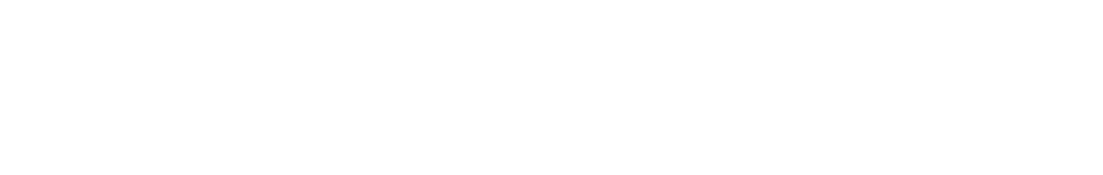

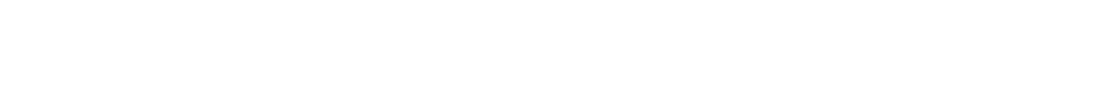

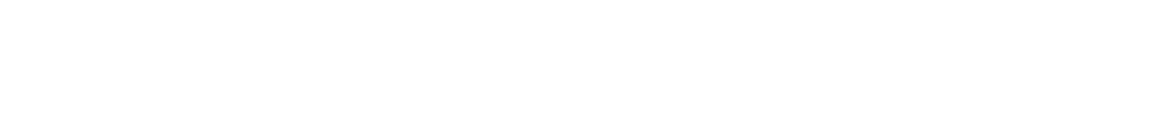

'slide_images/eq_corr_mean.png'

In [73]:
# The generative model: shared factor Z + idiosyncratic noise
eq(r"""$\displaystyle
\underbrace{Z\sim N(0,1)}_{\text{shared factor}}\ ,\quad
\underbrace{\varepsilon_i\overset{\text{iid}}{\sim}N(0,1)}_{\text{idiosyncratic}}\ ,\qquad
X_i=\sqrt{\rho}\,Z+\sqrt{1-\rho}\,\varepsilon_i$""", "eq_corr_model")

# Resulting moments: unit variance, pairwise correlation rho
eq(r"""$\displaystyle
\mathbb{E}[X_i]=0,\qquad \operatorname{Var}(X_i)=1,\qquad
\operatorname{Corr}(X_i,X_j)=\rho\ \ (i\neq j)$""", "eq_corr_props")

# Why it stalls: the shared sqrt(rho) Z term never averages away
eq(r"""$\displaystyle
\bar X_n=\sqrt{\rho}\,Z+\sqrt{1-\rho}\,\bar\varepsilon_n,\qquad
\operatorname{Var}(\bar X_n)=\rho+\frac{1-\rho}{n}\ \xrightarrow[\,n\to\infty\,]{}\ \rho$""", "eq_corr_mean")

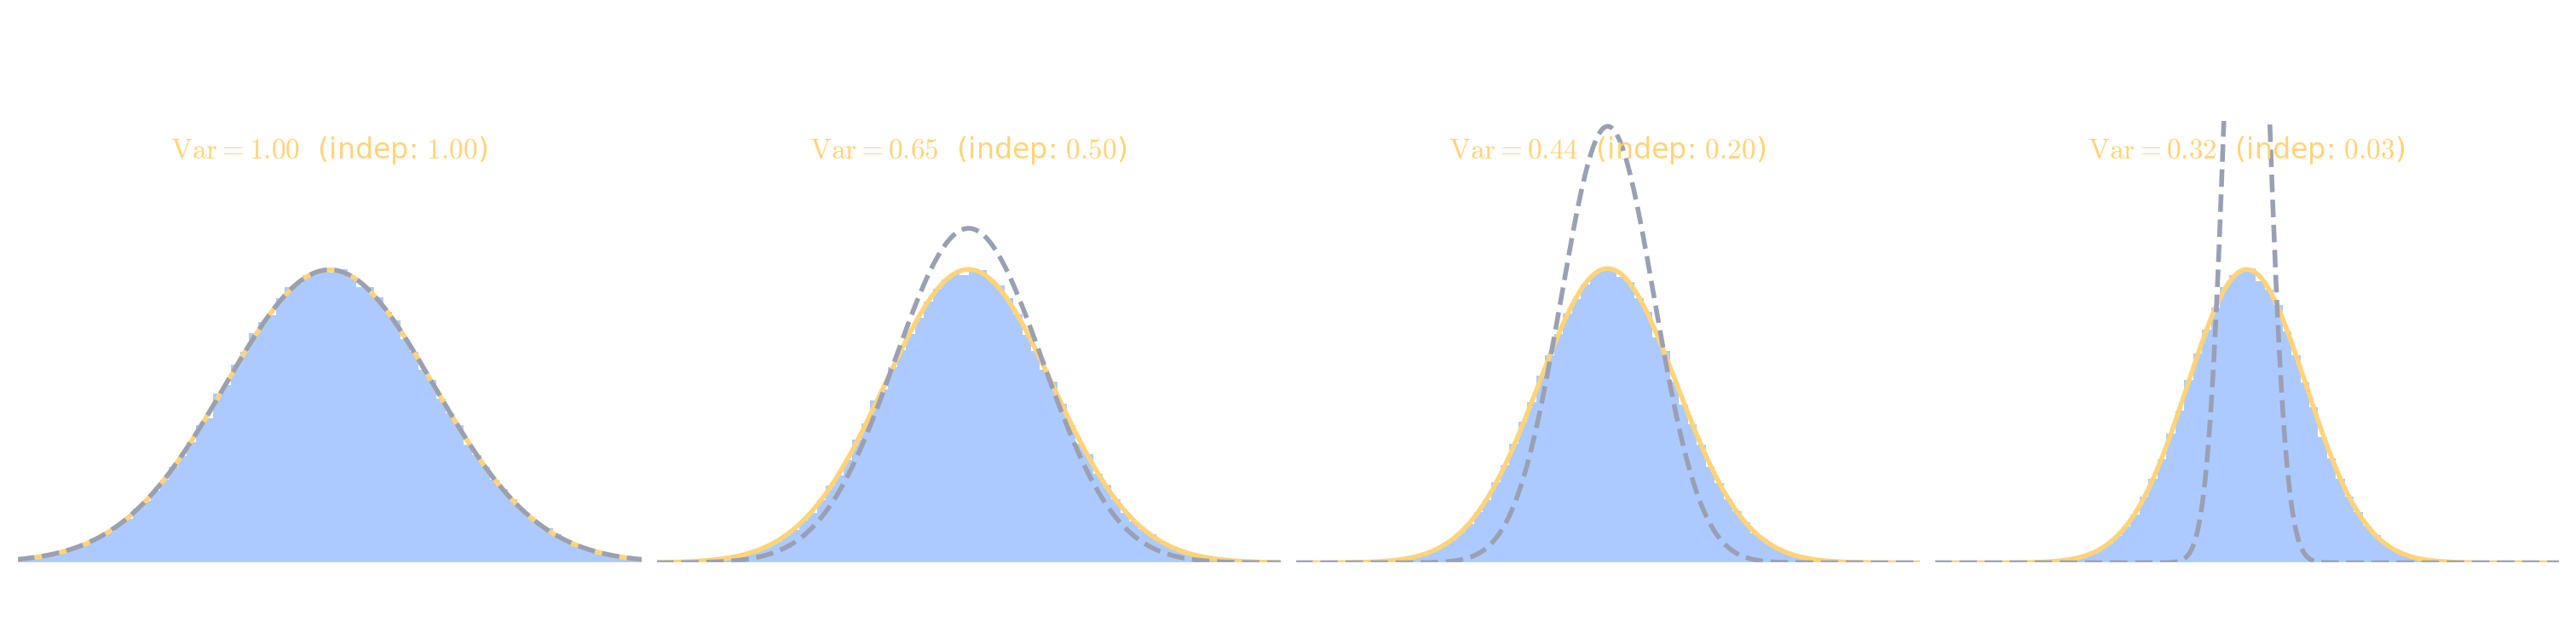

'slide_images/correlated_clt.png'

In [69]:
rho = 0.3; N = 300_000; lo, hi = -3, 3
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), constrained_layout=True)
for ax, k in zip(axes, [1, 2, 5, 30]):
    Z = rng.standard_normal((N, 1)); eps = rng.standard_normal((N, k))
    means = (np.sqrt(rho) * Z + np.sqrt(1 - rho) * eps).mean(1)
    var_true = (1 + (k - 1) * rho) / k; sd_true = np.sqrt(var_true); sd_naive = np.sqrt(1 / k)
    counts, _, _ = ax.hist(means, bins=70, range=(lo, hi), density=True, color=BLUE, alpha=0.7)
    x = np.linspace(lo, hi, 400); peak_t = 1 / (sd_true * np.sqrt(2 * np.pi))
    ax.plot(x, peak_t * np.exp(-x**2 / (2 * sd_true**2)), color=GOLD, lw=2)                 # true
    ax.plot(x, (1/(sd_naive*np.sqrt(2*np.pi))) * np.exp(-x**2/(2*sd_naive**2)),
            color=GREY, lw=2, ls="--")                                                       # naive (if independent)
    ax.set_title(f"n = {k}")
    ax.text(0.5, 0.97, rf"$\mathrm{{Var}}={var_true:.2f}$  (indep: ${1/k:.2f}$)",
            transform=ax.transAxes, color=GOLD, fontsize=12, ha="center", va="top")
    ax.set_ylim(0, 1.5 * max(counts.max(), peak_t)); ax.set_xlim(lo, hi)
    ax.set_xticks([-2, 0, 2]); ax.set_yticks([])
fig.suptitle(r"Correlated draws ($\rho=0.3$): variance stalls near $\rho$, doesn't reach 0", fontsize=17)
save(fig, "correlated_clt")

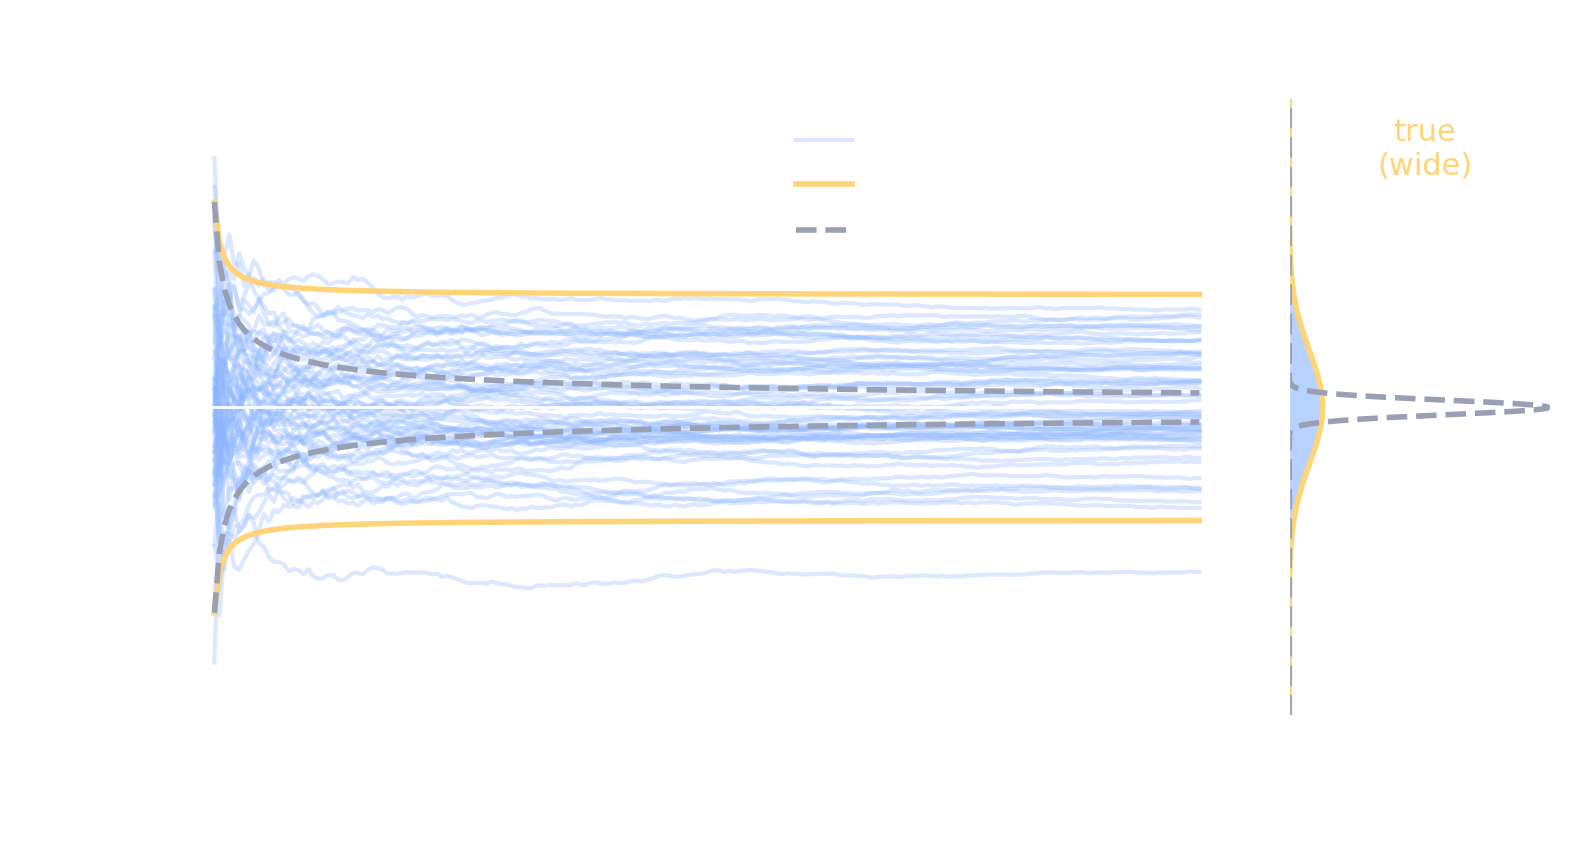

'slide_images/funnel_correlated.png'

In [67]:
rho = 0.3; n_max = 200; paths_show = 60; paths_dist = 40_000
Z   = rng.standard_normal((paths_dist, 1))          # one shared factor per run
eps = rng.standard_normal((paths_dist, n_max))      # idiosyncratic noise
X   = np.sqrt(rho) * Z + np.sqrt(1 - rho) * eps      # Corr(X_i, X_j) = rho, Var = 1
run = np.cumsum(X, axis=1) / np.arange(1, n_max + 1)
ns  = np.arange(1, n_max + 1)
sd_corr = np.sqrt((1 + (ns - 1) * rho) / ns)         # true SD of the mean under correlation

GREY = "#9aa0b4"
fig, (ax, axr) = plt.subplots(1, 2, figsize=(9, 4), sharey=True,
                              gridspec_kw={"width_ratios": [4, 1], "wspace": 0.06})
lines = ax.plot(ns, run[:paths_show].T, color=BLUE, alpha=0.3)
lines[0].set_label(r"one run of $\bar X_n$")
ax.axhline(0, color="white", lw=1)
ax.plot(ns,  2 * sd_corr, color=GOLD, lw=2, label=r"$\pm2\,$SD, correlated ($\rho=0.3$)")
ax.plot(ns, -2 * sd_corr, color=GOLD, lw=2)
ax.plot(ns,  2 / np.sqrt(ns), color=GREY, lw=2, ls="--", label=r"$\pm2\,\sigma/\sqrt{n}$ (if independent)")
ax.plot(ns, -2 / np.sqrt(ns), color=GREY, lw=2, ls="--")
ax.set_xlabel("n"); ax.set_ylabel(r"$\bar X_n$"); ax.set_ylim(-3, 3); ax.legend(loc="upper right", fontsize=10)

lo, hi = -3, 3
edges = np.linspace(lo, hi, 70); bw = edges[1] - edges[0]; cen = (edges[:-1] + edges[1:]) / 2
cnt, _ = np.histogram(run[:, -1], bins=edges); dens = cnt / (paths_dist * bw)
axr.barh(cen, dens, height=bw, color=BLUE, alpha=0.6)
yy = np.linspace(lo, hi, 400); sd_true = sd_corr[-1]; sd_naive = 1 / np.sqrt(n_max)
axr.plot(np.exp(-yy**2 / (2*sd_true**2))  / (sd_true *np.sqrt(2*np.pi)), yy, color=GOLD, lw=2)
axr.plot(np.exp(-yy**2 / (2*sd_naive**2)) / (sd_naive*np.sqrt(2*np.pi)), yy, color=GREY, lw=2, ls="--")
axr.set_xticks([]); axr.set_xlabel("density")
axr.text(0.5, 0.97, "true\n(wide)", transform=axr.transAxes, color=GOLD, fontsize=11, ha="center", va="top")
for s in ("top", "right", "bottom"):
    axr.spines[s].set_visible(False)
fig.suptitle("Correlation breaks it too  (variance stalls at a floor)", fontsize=16)
save(fig, "funnel_correlated")

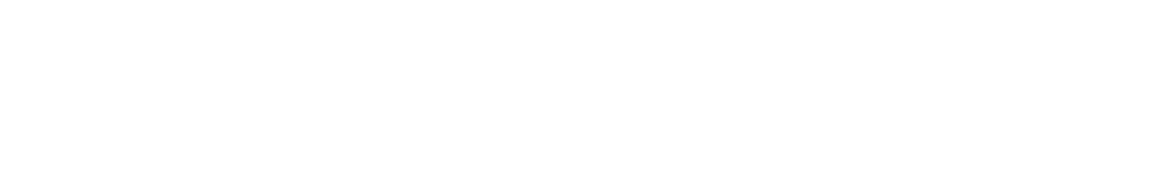

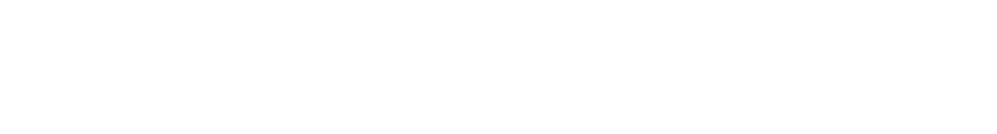

'slide_images/eq_neuron_init.png'

In [75]:
eq(r"""$\displaystyle
z=\sum_{i=1}^{n} w_i x_i \ \ \xrightarrow{\ \text{CLT}\ }\ \
z\approx N\!\Big(0,\ \sigma_w^{2}\textstyle\sum_i x_i^{2}\Big),
\qquad w_i\overset{\text{iid}}{\sim}(0,\sigma_w^{2})$""", "eq_neuron_clt")

eq(r"""$\displaystyle
\operatorname{Var}(z)\approx n\,\sigma_w^{2}\,\overline{x^{2}}
\ \ \Longrightarrow\ \
\sigma_w^{2}=\frac{1}{n}\ (\text{Xavier}),\quad \frac{2}{n}\ (\text{He})$""", "eq_neuron_init")

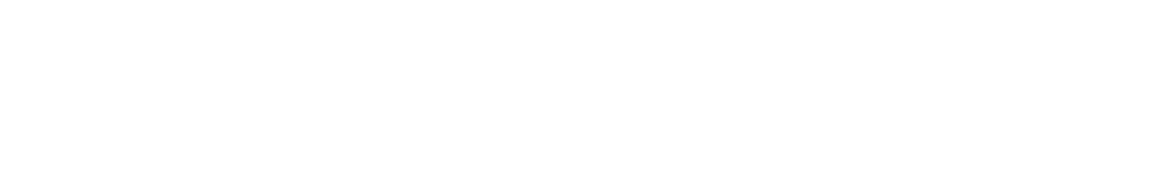

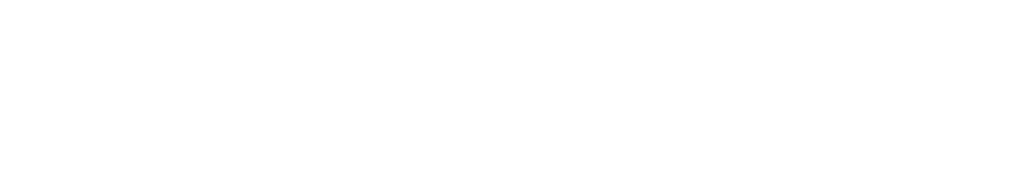

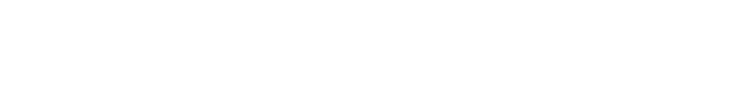

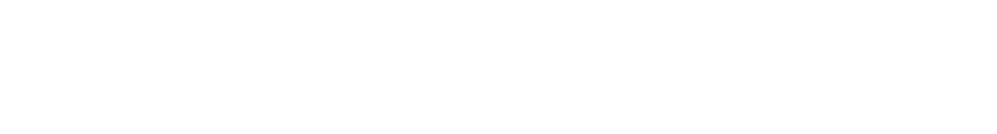

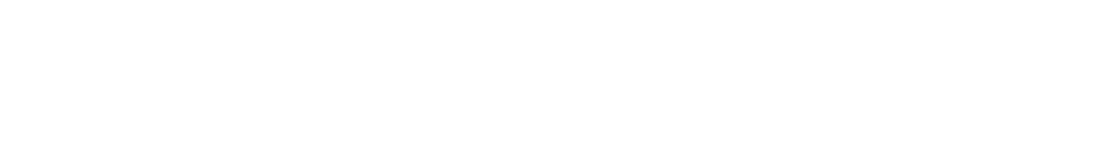

'slide_images/eq_neuron_sqrtn.png'

In [74]:
# Step 2 - CLT makes the sum Gaussian
eq(r"""$\displaystyle
z=\sum_{i=1}^{n} w_i x_i \ \ \xrightarrow{\ \text{CLT}\ }\ \
z\approx N\!\Big(0,\ \sigma_w^{2}\textstyle\sum_i x_i^{2}\Big),
\qquad w_i\overset{\text{iid}}{\sim}(0,\sigma_w^{2})$""", "eq_neuron_clt")

# Step 3 - variances add (independence)
eq(r"""$\displaystyle
\operatorname{Var}(z)=\sum_{i=1}^{n}\operatorname{Var}(w_i x_i)
=\sum_{i=1}^{n} x_i^{2}\,\operatorname{Var}(w_i)
=\sigma_w^{2}\sum_{i=1}^{n} x_i^{2}$""", "eq_neuron_var")

# Step 3 - Gaussian inputs collapse the sum to n*sigma_x^2
eq(r"""$\displaystyle
x_i\overset{\text{iid}}{\sim}N(0,\sigma_x^{2})
\ \ \Longrightarrow\ \
\operatorname{Var}(z)=n\,\sigma_w^{2}\,\sigma_x^{2}$""", "eq_neuron_x")

# Step 5 - kill the n: Xavier / He
eq(r"""$\displaystyle
\operatorname{Var}(z)\approx n\,\sigma_w^{2}\,\overline{x^{2}}
\ \ \Longrightarrow\ \
\sigma_w^{2}=\frac{1}{n}\ (\text{Xavier}),\quad \frac{2}{n}\ (\text{He})$""", "eq_neuron_init")

# Punchline - same sqrt(n) as the standard error
eq(r"""$\displaystyle
\operatorname{SD}(z)\propto \sigma_w\sqrt{n}
\ \ \Longrightarrow\ \ \sigma_w\propto\frac{1}{\sqrt{n}}
\qquad(\text{same }\sqrt{n}\text{ as }\ \sigma/\sqrt{n})$""", "eq_neuron_sqrtn")

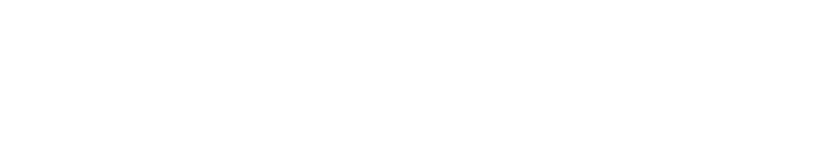

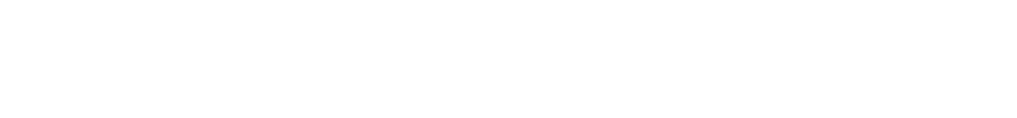

'slide_images/eq_D_var.png'

In [90]:
# D for means: difference of sample means
eq(r"""$\displaystyle
D=\bar A-\bar B\ \sim\ N\!\left(\mu_A-\mu_B,\ \ \frac{\sigma_A^2}{n_A}+\frac{\sigma_B^2}{n_B}\right)$""",
   "eq_D_mean")

# D for variances: difference of sample variances (Gaussian by the CLT too)
eq(r"""$\displaystyle
\begin{gathered}
D=s_A^2-s_B^2\ \overset{\text{CLT}}{\approx}\ N\!\left(\sigma_A^2-\sigma_B^2,\ \ \operatorname{Var}(s_A^2)+\operatorname{Var}(s_B^2)\right)
\end{gathered}$""",
   "eq_D_var")